# Работа по теме «Методы снижения размерности. Методы кластеризации»

## Описание

Работа предполагает самостоятельное исследование двух наборов данных. Основная задача — показать умение применять и интерпретировать методы снижения размерности и различные алгоритмы кластеризации.

**Критерии оценки:**
- Данные изучены и предобработаны при необходимости.
- Применены различные методы снижения размерности (PCA).
- Использованы разные методы кластеризации (KMeans, иерархическая, DBSCAN).
- Методы правильно объяснены и применены.
- Полученные кластеры корректно интерпретированы.

Итогом каждого блока является кластеризация с подробной интерпретацией.

## Импорт библиотек

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

sns.set_style('whitegrid')
%matplotlib inline

## Анализ клиентов магазина

Датасет `Customers.csv` — синтетические данные о 2000 клиентах магазина. Признаки:
- CustomerID (игнорируется)
- Gender, Age, Annual Income ($), Spending Score (1-100), Profession, Work Experience, Family Size

Цель: сегментировать клиентов для понимания целевых групп.

### Загрузка и первичный осмотр

Загружаем данные и сразу переименовываем столбцы с неудобными названиями для удобства дальнейшей работы.

In [66]:
df_cust = pd.read_csv('Customers.csv')
df_cust.rename(columns={
    'Annual Income ($)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

print('Размер:', df_cust.shape)
df_cust.head()

Размер: (2000, 8)


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Profession,Work Experience,Family Size
0,1,Male,19,15000,39,Healthcare,1,4
1,2,Male,21,35000,81,Engineer,3,3
2,3,Female,20,86000,6,Engineer,1,1
3,4,Female,23,59000,77,Lawyer,0,2
4,5,Female,31,38000,40,Entertainment,2,6


In [67]:
df_cust.info()
print(df_cust.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   CustomerID       2000 non-null   int64 
 1   Gender           2000 non-null   object
 2   Age              2000 non-null   int64 
 3   Annual_Income    2000 non-null   int64 
 4   Spending_Score   2000 non-null   int64 
 5   Profession       1965 non-null   object
 6   Work Experience  2000 non-null   int64 
 7   Family Size      2000 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 125.1+ KB
CustomerID          0
Gender              0
Age                 0
Annual_Income       0
Spending_Score      0
Profession         35
Work Experience     0
Family Size         0
dtype: int64


### Предобработка

Удалим идентификатор, закодируем Gender и Profession через OneHotEncoder, числовые признаки стандартизируем.


In [68]:
# немного понтов :)
df_cust.columns = (df_cust.columns
                   .str.replace(' ', '_')
                   .str.replace(r'[\(\)]', '', regex=True)
                   .str.replace('$', '', regex=False))


df_cust = df_cust.drop(columns=['CustomerID'])

cat_cols = ['Gender', 'Profession']
num_cols = ['Age', 'Annual_Income', 'Spending_Score', 'Work_Experience', 'Family_Size']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])

X_cust = preprocessor.fit_transform(df_cust)
X_cust.shape

(2000, 15)

### Снижение размерности (PCA)

PCA позволяет перейти к меньшему числу признаков, сохраняя основную изменчивость. Подберём число компонент, объясняющих не менее 85% дисперсии.

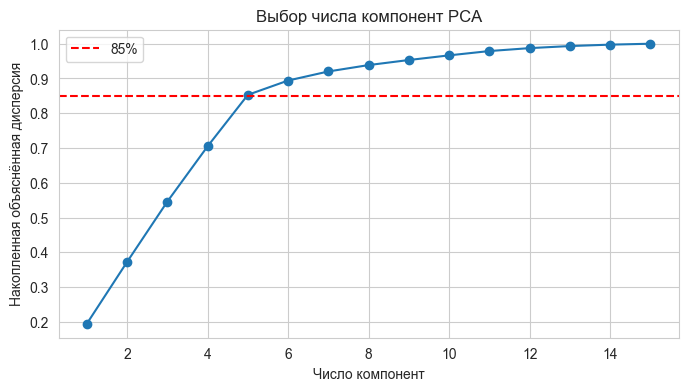

Оставлено компонент: 5 (дисперсия 85.30%)


In [69]:
pca_full = PCA().fit(X_cust)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, 'o-')
plt.axhline(y=0.85, color='r', linestyle='--', label='85%')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная объяснённая дисперсия')
plt.legend()
plt.title('Выбор числа компонент PCA')
plt.show()

pca = PCA(n_components=0.85, random_state=42)
X_cust_pca = pca.fit_transform(X_cust)
print(f'Оставлено компонент: {X_cust_pca.shape[1]} (дисперсия {pca.explained_variance_ratio_.sum():.2%})')

### Кластеризация KMeans

Подберём оптимальное число кластеров по силуэтному коэффициенту и визуализируем результат в пространстве первых двух главных компонент.

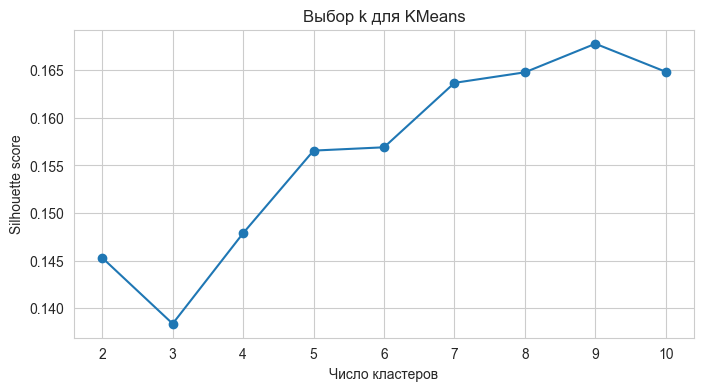

Оптимальное число кластеров: 9


In [70]:
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_cust_pca)
    sil_scores.append(silhouette_score(X_cust_pca, labels))

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_scores, 'o-')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette score')
plt.title('Выбор k для KMeans')
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f'Оптимальное число кластеров: {best_k}')

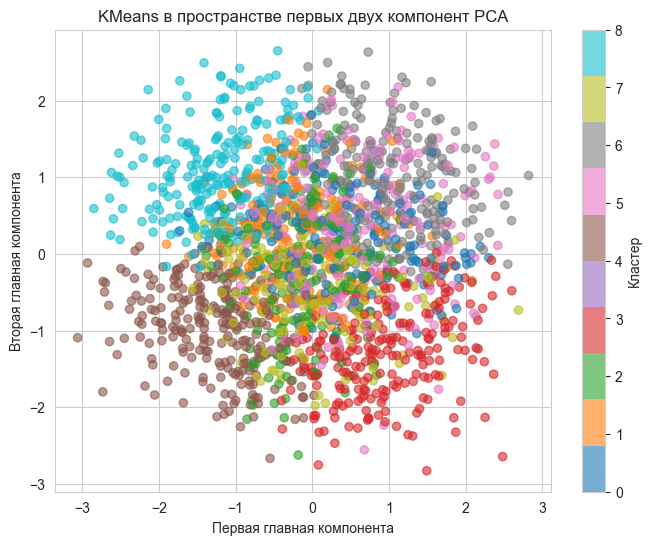

In [71]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init='auto')
clusters_km = kmeans.fit_predict(X_cust_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_cust_pca[:, 0], X_cust_pca[:, 1], c=clusters_km, cmap='tab10', alpha=0.6)
plt.colorbar(label='Кластер')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('KMeans в пространстве первых двух компонент PCA')
plt.show()

### Иерархическая кластеризация (AgglomerativeClustering)

Второй метод — агломеративная иерархическая кластеризация. Построим дендрограмму и сравним разбиение с KMeans.

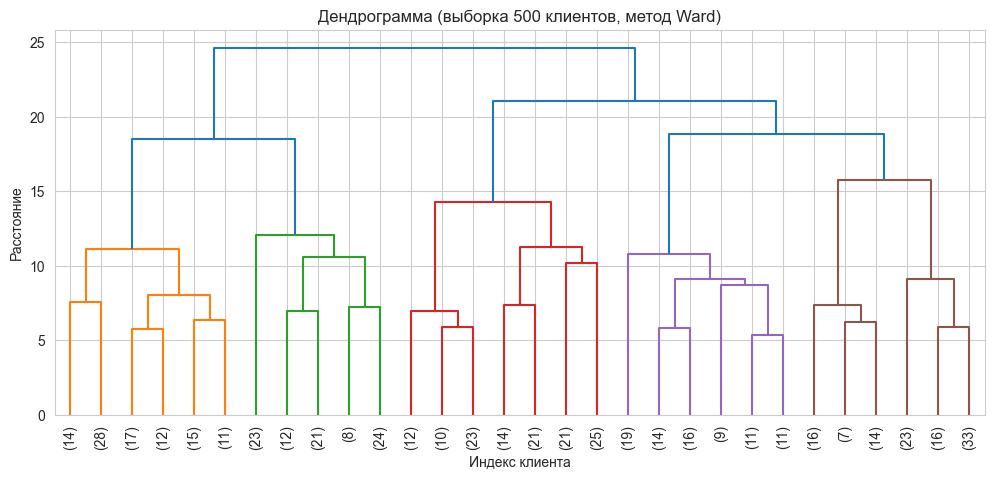

In [72]:
plt.figure(figsize=(12, 5))
# используем небольшую выборку для читаемости дендрограммы
sample_idx = np.random.choice(len(X_cust_pca), size=500, replace=False)
Z = linkage(X_cust_pca[sample_idx], method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Дендрограмма (выборка 500 клиентов, метод Ward)')
plt.xlabel('Индекс клиента')
plt.ylabel('Расстояние')
plt.show()

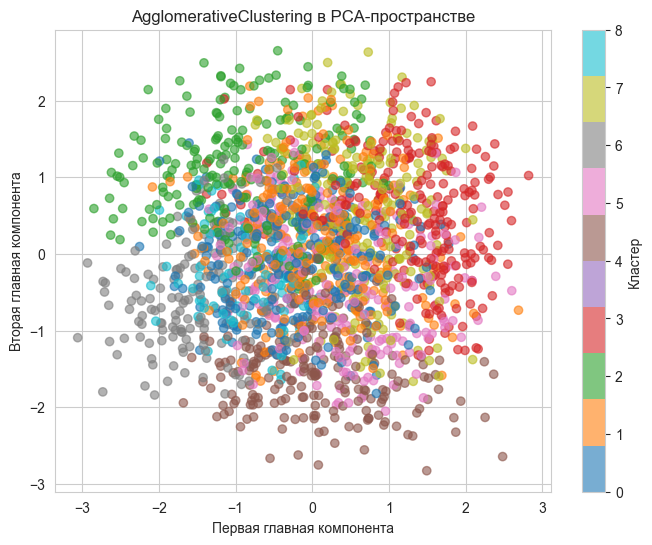

Силуэт для иерархической кластеризации: 0.099


In [73]:
agg = AgglomerativeClustering(n_clusters=best_k, metric='euclidean', linkage='ward')
clusters_agg = agg.fit_predict(X_cust_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_cust_pca[:, 0], X_cust_pca[:, 1], c=clusters_agg, cmap='tab10', alpha=0.6)
plt.colorbar(label='Кластер')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('AgglomerativeClustering в PCA-пространстве')
plt.show()
print('Силуэт для иерархической кластеризации:',
      round(silhouette_score(X_cust_pca, clusters_agg), 3))

### Интерпретация кластеров (KMeans)

Присвоим метки KMeans и проанализируем средние значения признаков, а также распределение категорий.

In [74]:
df_cust['Cluster'] = clusters_km
print('Средние значения числовых признаков по кластерам:')
display(df_cust.groupby('Cluster')[num_cols].mean())

Средние значения числовых признаков по кластерам:


,Age,Annual_Income,Spending_Score,Work_Experience,Family_Size
Cluster,,,,,
0,77.852217,97874.709360,77.684729,3.684729,5.285714
1,31.572139,76720.930348,33.019900,2.910448,5.696517
2,60.310000,153230.270000,67.095000,1.450000,2.150000
3,22.897436,148363.264957,70.081197,5.675214,5.376068
4,26.528736,71030.187739,75.720307,2.823755,2.574713
5,69.132530,114760.694779,45.445783,9.497992,2.799197
6,70.541284,142344.871560,29.885321,2.922018,5.821101
7,19.718750,135539.348958,25.666667,6.026042,2.338542
8,62.181818,68768.938017,29.661157,1.479339,2.247934


In [75]:
for col in cat_cols:
    print(f'Распределение {col} по кластерам:')
    display(pd.crosstab(df_cust['Cluster'], df_cust[col], normalize='index'))
    print()

Распределение Gender по кластерам:


Gender,Female,Male
Cluster,,
0,0.625616,0.374384
1,0.606965,0.393035
2,0.610000,0.390000
3,0.576923,0.423077
4,0.555556,0.444444
5,0.546185,0.453815
6,0.600917,0.399083
7,0.604167,0.395833
8,0.628099,0.371901



Распределение Profession по кластерам:


Profession,Artist,Doctor,Engineer,Entertainment,Executive,Healthcare,Homemaker,Lawyer,Marketing
Cluster,,,,,,,,,
0,0.350000,0.045000,0.110000,0.125000,0.065000,0.205000,0.015000,0.045000,0.040000
1,0.234694,0.076531,0.071429,0.132653,0.117347,0.178571,0.056122,0.091837,0.040816
2,0.297980,0.090909,0.095960,0.151515,0.080808,0.171717,0.010101,0.070707,0.030303
3,0.321739,0.069565,0.069565,0.108696,0.065217,0.208696,0.030435,0.069565,0.056522
4,0.369650,0.085603,0.073930,0.116732,0.077821,0.147860,0.027237,0.062257,0.038911
5,0.267490,0.102881,0.127572,0.078189,0.106996,0.160494,0.049383,0.053498,0.053498
6,0.287736,0.099057,0.103774,0.122642,0.089623,0.160377,0.028302,0.080189,0.028302
7,0.315789,0.063158,0.073684,0.094737,0.063158,0.178947,0.047368,0.105263,0.057895
8,0.343096,0.096234,0.092050,0.146444,0.037657,0.150628,0.012552,0.079498,0.041841


**Выводы по клиентам:**
- Выделены группы с чёткими различиями по доходу и Spending Score (премиум, эконом и т.д.).
- Иерархическая кластеризация даёт схожее разбиение, подтверждая устойчивость сегментов.
- Результаты могут быть использованы для таргетированных маркетинговых кампаний.

## Климат и болезни

Датасет `climate_disease_dataset.csv` содержит показатели климата, загрязнения, заболеваемости и здравоохранения для 120 стран за 2000–2023 годы.

Цель: кластеризация стран по уровню экологических и эпидемиологических рисков.

Для интерпретации будем работать с агрегированными по странам средними за весь период.

### Загрузка и осмотр

In [76]:
df_clim = pd.read_csv('climate_disease_dataset.csv')
print('Размер:', df_clim.shape)
df_clim.head()

Размер: (34560, 12)


,year,month,country,region,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,2000,1,Palestinian Territory,Central,28.132468,152.083870,110.487231,12.000000,53,145,113,1068
1,2000,2,Palestinian Territory,Central,30.886500,119.591418,83.467928,12.000000,132,48,113,1068
2,2000,3,Palestinian Territory,Central,31.366433,95.876124,93.095292,12.000000,34,80,113,1068
3,2000,4,Palestinian Territory,Central,28.481870,175.315731,105.530192,9.395894,23,133,113,1068
4,2000,5,Palestinian Territory,Central,26.890370,191.445990,60.205979,9.935726,39,74,113,1068


In [77]:
df_clim.info()
print('Пропуски:')
print(df_clim.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34560 entries, 0 to 34559
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   year                34560 non-null  int64  
 1   month               34560 non-null  int64  
 2   country             34560 non-null  object 
 3   region              34560 non-null  object 
 4   avg_temp_c          34560 non-null  float64
 5   precipitation_mm    34560 non-null  float64
 6   air_quality_index   34560 non-null  float64
 7   uv_index            34560 non-null  float64
 8   malaria_cases       34560 non-null  int64  
 9   dengue_cases        34560 non-null  int64  
 10  population_density  34560 non-null  int64  
 11  healthcare_budget   34560 non-null  int64  
dtypes: float64(4), int64(6), object(2)
memory usage: 3.2+ MB
Пропуски:
year                  0
month                 0
country               0
region                0
avg_temp_c            0
precipitation

### Агрегация по странам

Сгруппируем данные по `Country`, усреднив числовые показатели. Пропуски предварительно заполним медианой по каждой стране.

Числовые признаки определяем автоматически (исключая `Country`, `Region`, `Year`).

In [78]:
# Определяем числовые столбцы, исключая идентификаторы
num_cols_all = df_clim.select_dtypes(include=np.number).columns.tolist()
exclude_cols = ['year']
feature_cols = [c for c in num_cols_all if c not in exclude_cols]
print('Числовые признаки для анализа:')
print(feature_cols)

# заполняем пропуски медианой по стране
df_clim[feature_cols] = df_clim.groupby('country')[feature_cols].transform(
    lambda x: x.fillna(x.median())
)

# агрегируем средние по стране
df_country = df_clim.groupby('country', as_index=False).agg(
    Region = ('region', 'first'),
    **{col: (col, 'mean') for col in feature_cols}
)
print('Размер после агрегации (стран):', df_country.shape)
df_country.head()

Числовые признаки для анализа:
['month', 'avg_temp_c', 'precipitation_mm', 'air_quality_index', 'uv_index', 'malaria_cases', 'dengue_cases', 'population_density', 'healthcare_budget']
Размер после агрегации (стран): (120, 11)


,country,Region,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
0,American Samoa,East,6.5,20.129517,225.060643,10.543390,10.388125,63.993056,70.430556,289.0,4667.0
1,Antarctica (the territory South of 60 deg S),North,6.5,20.914754,88.238572,16.757147,10.664012,46.868056,64.447917,289.0,4256.0
2,Antigua and Barbuda,South,6.5,19.944344,234.316213,35.588115,10.544012,71.430556,79.364583,364.0,3077.0
3,Armenia,Central,6.5,18.213447,224.719973,20.214942,9.913392,63.277778,70.326389,178.0,4020.0
4,Aruba,North,6.5,14.303888,157.079155,19.740616,8.822024,50.197917,55.885417,478.0,3986.0


### Предобработка

Масштабируем числовые признаки. `Region` отложим для интерпретации.

In [79]:
X_clim = df_country[feature_cols].copy()

scaler = StandardScaler()
X_clim_scaled = scaler.fit_transform(X_clim)
print('Форма масштабированной матрицы:', X_clim_scaled.shape)

Форма масштабированной матрицы: (120, 9)


### Снижение размерности (PCA)

Для визуализации сократим размерность до двух компонент.

In [80]:
pca_clim = PCA(n_components=2, random_state=42)
X_clim_pca = pca_clim.fit_transform(X_clim_scaled)
print(f'Объяснённая дисперсия двумя компонентами: {pca_clim.explained_variance_ratio_.sum():.2%}')

Объяснённая дисперсия двумя компонентами: 73.50%


### Кластеризация KMeans

Силуэтный анализ для выбора оптимального числа кластеров.

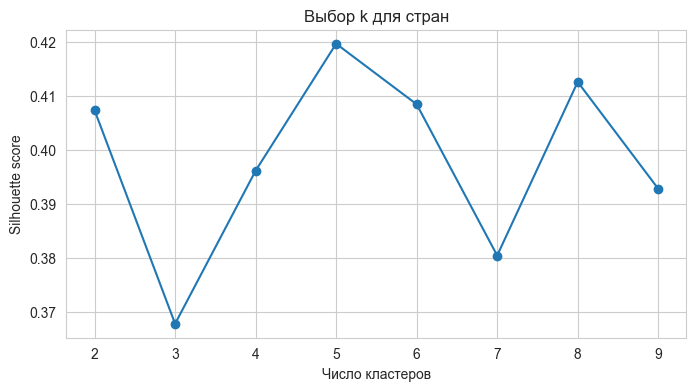

Оптимальное число кластеров: 5


In [81]:
sil_clim = []
K_range = range(2, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_clim_pca)
    sil_clim.append(silhouette_score(X_clim_pca, labels))

plt.figure(figsize=(8, 4))
plt.plot(K_range, sil_clim, 'o-')
plt.xlabel('Число кластеров')
plt.ylabel('Silhouette score')
plt.title('Выбор k для стран')
plt.show()

best_k_clim = K_range[np.argmax(sil_clim)]
print(f'Оптимальное число кластеров: {best_k_clim}')

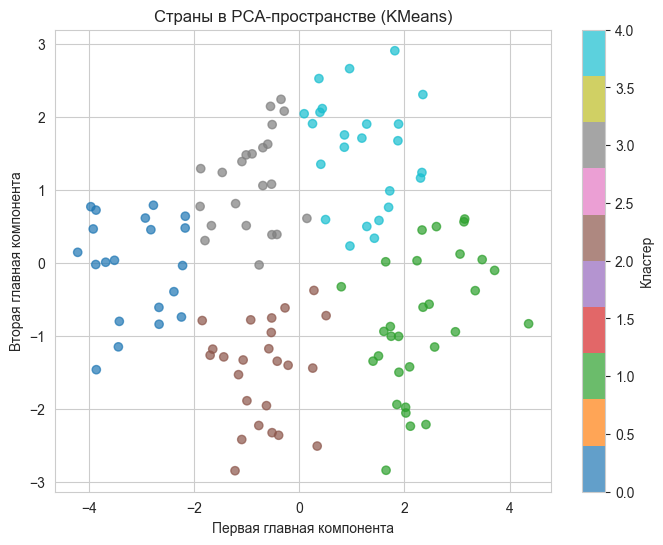

In [82]:
kmeans_clim = KMeans(n_clusters=best_k_clim, random_state=42, n_init='auto')
clusters_km_clim = kmeans_clim.fit_predict(X_clim_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_clim_pca[:, 0], X_clim_pca[:, 1], c=clusters_km_clim, cmap='tab10', alpha=0.7)
plt.colorbar(label='Кластер')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('Страны в PCA-пространстве (KMeans)')
plt.show()

### DBSCAN для обнаружения аномалий

DBSCAN не требует задания числа кластеров и выявляет шумовые точки. Подберём `eps` по k-расстояниям.

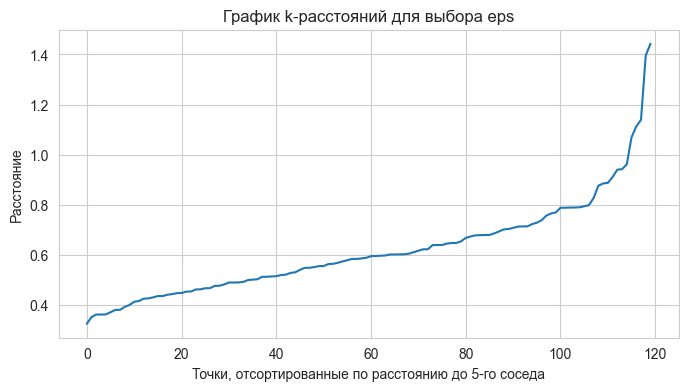

In [83]:
# Оценка eps по расстоянию до 5-го соседа
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_clim_pca)
distances, _ = nn.kneighbors(X_clim_pca)
k_dist = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_dist)
plt.xlabel('Точки, отсортированные по расстоянию до 5-го соседа')
plt.ylabel('Расстояние')
plt.title('График k-расстояний для выбора eps')
plt.show()

Распределение меток DBSCAN:
0    120
Name: count, dtype: int64


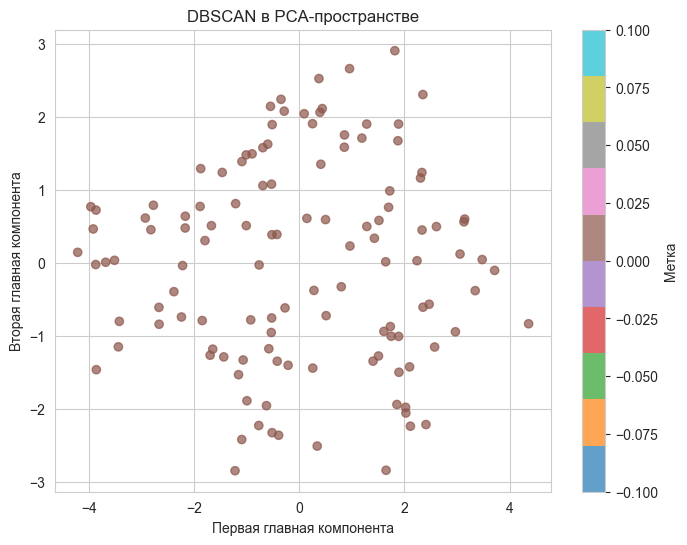

In [84]:
dbscan = DBSCAN(eps=1.0, min_samples=3)
clusters_db = dbscan.fit_predict(X_clim_pca)

print('Распределение меток DBSCAN:')
print(pd.Series(clusters_db).value_counts())

plt.figure(figsize=(8, 6))
plt.scatter(X_clim_pca[:, 0], X_clim_pca[:, 1], c=clusters_db, cmap='tab10', alpha=0.7)
plt.colorbar(label='Метка')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.title('DBSCAN в PCA-пространстве')
plt.show()

noise_mask = clusters_db == -1
if noise_mask.any():
    print('Страны-выбросы:')
    print(df_country.loc[noise_mask, ['Country', 'Region']])

### Интерпретация кластеров (KMeans)

Добавим метки KMeans и проанализируем средние значения признаков и распределение регионов.

In [85]:
df_country['Cluster'] = clusters_km_clim
print('Средние значения признаков по кластерам (KMeans):')
display(df_country.groupby('Cluster')[feature_cols].mean())

Средние значения признаков по кластерам (KMeans):


,month,avg_temp_c,precipitation_mm,air_quality_index,uv_index,malaria_cases,dengue_cases,population_density,healthcare_budget
Cluster,,,,,,,,,
0,6.5,13.717776,125.744089,20.346505,8.715929,46.085417,52.652778,283.600000,4070.150000
1,6.5,24.357171,213.719514,75.960907,11.045015,87.314931,91.578241,200.233333,1064.233333
2,6.5,14.838120,198.390281,59.013160,9.041633,67.543547,67.794126,255.291667,1886.666667
3,6.5,20.780372,179.524540,20.013776,10.445439,62.971275,70.696812,300.272727,4053.000000
4,6.5,26.211432,228.449308,29.673154,11.368114,79.782407,88.757668,317.333333,3499.250000


In [86]:
print('Распределение регионов по кластерам (доля):')
display(pd.crosstab(df_country['Cluster'], df_country['Region'], normalize='index'))

Распределение регионов по кластерам (доля):


Region,Central,East,North,South,West
Cluster,,,,,
0,0.200000,0.150000,0.250000,0.250000,0.150000
1,0.166667,0.200000,0.133333,0.200000,0.300000
2,0.333333,0.083333,0.166667,0.166667,0.250000
3,0.227273,0.045455,0.227273,0.272727,0.227273
4,0.208333,0.125000,0.250000,0.125000,0.291667


**Выводы по климатическому датасету:**
- KMeans выделил группы стран со схожими климатическими и эпидемиологическими профилями (тропические, умеренные, высокозагрязнённые и т.д.).
- DBSCAN пометил несколько стран как выбросы — государства с экстремальными значениями показателей.
- Совместное использование двух методов даёт полную картину структуры данных.